# Arena-style rank spread confidence intervals

Applies the confidence-interval / rank-spread method described in the Arena ranking-method blog post (https://arena.ai/blog/ranking-method/) to the same leaderboard dataset and ranking methods as `simulation_38.ipynb`.

For each candidate `c`, given a score confidence interval `[lo, hi]` for every candidate:
- **best-case rank**: assume `c`'s true score equals `hi[c]` and every *other* candidate's true score equals its own `lo`; `c`'s rank under that assignment is its best-case (optimistic) rank.
- **worst-case rank**: assume `c`'s true score equals `lo[c]` and every other candidate's true score equals its own `hi`; `c`'s rank under that assignment is its worst-case (pessimistic) rank.
- the **rank spread** is `[best_rank, worst_rank]`; two candidates are considered *tied* if their rank spreads overlap.

This differs from `simulation_38`'s `true_ranking_is_possible` chain check: that function tests global consistency of the *true* ranking against score CIs, whereas rank spread gives each candidate its own best/worst rank range and a pairwise tie relation, independent of the true ranking.

Score definitions per method (bootstrapped the same way as `simulation_38`'s Borda-score CI cells, but at `num_samples=100_000`, `n_resamples=1000`, `ci=0.95`):
- `borda` / `borda_peeling`: one-shot Borda win-rate score (peeling reuses the one-shot score's CI, since peeling has no independent scalar score of its own)
- `copeland` / `copeland_peeling`: one-shot Copeland net-win score (same reuse logic)
- `ml_argmax` / `ml_nonzero` / `ml_sampling`: one-shot maximal-lottery LP weight, solved once on the full candidate set per resample (all three peel/sample from the same underlying lottery, so they share this score's CI)

## Build the same population from the leaderboard dataset (identical to `simulation_38.ipynb`)

In [1]:
from datasets import load_dataset
import numpy as np

ds = load_dataset("lmarena-ai/leaderboard-dataset", "text_style_control", split="latest")

M = 30  # matches PairwiseData(ds, M=30, N=30) in simulation_36 / simulation_37

all_categories = sorted(set(ds['category']))
subgroup_categories = [c for c in all_categories if c != 'overall']

models_per_category = {c: set() for c in all_categories}
for row in ds:
    models_per_category[row['category']].add(row['model_name'])

# restrict to models rated in every subgroup category, so the utility matrix is dense
common_models = set.intersection(*(models_per_category[c] for c in subgroup_categories))

overall_vote_counts = {row['model_name']: row['vote_count'] for row in ds if row['category'] == 'overall'}
candidates_ranked = sorted(common_models, key=lambda m: -overall_vote_counts[m])
candidates = candidates_ranked[:M]
candidates_to_idx = {c: i for i, c in enumerate(candidates)}

N = len(subgroup_categories)
subgroup_to_idx = {c: i for i, c in enumerate(subgroup_categories)}

population_utilities = np.zeros((N, M))
subgroup_vote_totals = np.zeros(N)

for row in ds:
    cat, model = row['category'], row['model_name']
    if cat in subgroup_to_idx and model in candidates_to_idx:
        i, j = subgroup_to_idx[cat], candidates_to_idx[model]
        population_utilities[i, j] = row['rating']
        subgroup_vote_totals[i] += row['vote_count']

# same final normalization Population uses: scale ratings to a max of 1
population_utilities = population_utilities / population_utilities.max()
voter_distr = subgroup_vote_totals / subgroup_vote_totals.sum()


class LeaderboardPopulation:
    def __init__(self, population_utilities, voter_distr):
        self.population_utilities = population_utilities
        self.voter_distr = voter_distr
        self.N, self.M = population_utilities.shape

    @property
    def avg_utilities(self):
        return self.voter_distr @ self.population_utilities


class LeaderboardCandidates:
    def __init__(self, M):
        self.M = M


population = LeaderboardPopulation(population_utilities, voter_distr)
pw = LeaderboardCandidates(M)

print(f'{pw.M} candidates, {population.N} subgroup categories')

/home/jennifer/miniconda3/envs/ld/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


30 candidates, 28 subgroup categories


## Fixed instance and per-candidate score bootstraps

Same fixed instance as `simulation_38`'s "Range of one-shot Borda scores" section: `num_samples=100_000` pairwise comparisons, pairs drawn uniformly, winners from the population utilities (Bradley-Terry, `beta=1.0`). `n_resamples=1000` bootstrap resamples of the win/loss outcomes, `ci=0.95`.

Three score families are bootstrapped (each is a `(n_resamples, M)` array):
- `borda_scores`: one-shot Borda win-rate, shared by `borda` and `borda_peeling`
- `copeland_scores`: one-shot Copeland net-win count, shared by `copeland` and `copeland_peeling`
- `ml_scores`: one-shot maximal-lottery LP weight (single LP solve on the full `M`-candidate set, no peeling), shared by `ml_argmax`, `ml_nonzero`, `ml_sampling`

In [2]:
import numpy as np
from scipy.special import expit
from utils_4 import ij_from_pairwise, borda_ranking

beta = 1.0
num_samples = 100_000
n_resamples = 1000
ci = 0.95

# fix a single instance: a sampled set of pairs + their win probabilities
# (uniform over pairs -- no real per-pair battle counts in this dataset)
empirical_pair_distribution = np.ones((pw.M, pw.M))
np.fill_diagonal(empirical_pair_distribution, 0.0)
empirical_pair_distribution /= empirical_pair_distribution.sum()

flattened = empirical_pair_distribution.ravel()
indices = np.random.choice(len(flattened), size=num_samples, p=flattened)
coords = np.array(np.unravel_index(indices, empirical_pair_distribution.shape)).T
model_As = coords[..., 0]
model_Bs = coords[..., 1]

u_diff = (population.population_utilities[:, model_As]
          - population.population_utilities[:, model_Bs])
p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)

true_ranking = np.argsort(-population.avg_utilities)

In [3]:
from tqdm.auto import tqdm
from utils_4 import _solve_maximal_lottery


def sample_ij_wins():
    mask = np.random.rand(num_samples) < p
    w_arr = np.where(mask, model_As, model_Bs)
    l_arr = np.where(mask, model_Bs, model_As)
    return ij_from_pairwise(w_arr, l_arr, pw.M)


def copeland_scores(ij_wins, tol=1e-9):
    # same net-win statistic copeland_ranking sorts by, exposed as a per-candidate score
    denom = ij_wins + ij_wins.T
    denom = np.where(denom == 0.0, 1.0, denom)
    m = (ij_wins - ij_wins.T) / denom
    return (m > tol).sum(axis=1) - (m < -tol).sum(axis=1)


def ml_lottery_scores(ij_wins):
    # one-shot maximal-lottery weight, no peeling: shared "score" for ml_argmax/ml_nonzero/ml_sampling
    with np.errstate(invalid='ignore', divide='ignore'):
        margins = np.where(ij_wins + ij_wins.T > 0,
                            (ij_wins - ij_wins.T) / (ij_wins + ij_wins.T), 0.0)
    return _solve_maximal_lottery(margins)


borda_scores = np.zeros((n_resamples, pw.M))
copeland_scores_arr = np.zeros((n_resamples, pw.M))
ml_scores = np.zeros((n_resamples, pw.M))

for r in tqdm(range(n_resamples)):
    ij_wins = sample_ij_wins()
    _, borda_scores[r] = borda_ranking(ij_wins, with_scores=True)
    copeland_scores_arr[r] = copeland_scores(ij_wins)
    ml_scores[r] = ml_lottery_scores(ij_wins)

100%|██████████| 1000/1000 [00:06<00:00, 146.17it/s]


In [4]:
alpha = 1.0 - ci

def percentile_ci(scores):
    lo, hi = np.percentile(scores, [100 * alpha / 2, 100 * (1 - alpha / 2)], axis=0)
    return lo, hi

score_families = {
    'borda':    borda_scores,
    'copeland': copeland_scores_arr,
    'ml':       ml_scores,
}

score_ci = {name: percentile_ci(scores) for name, scores in score_families.items()}

# map each of the 7 ranking methods from simulation_38 to the score family whose CI it reuses
method_to_family = {
    'borda':            'borda',
    'borda_peeling':    'borda',
    'copeland':         'copeland',
    'copeland_peeling': 'copeland',
    'ml_argmax':        'ml',
    'ml_nonzero':       'ml',
    'ml_sampling':      'ml',
}

for name, (lo, hi) in score_ci.items():
    print(f'{name}: mean CI width = {(hi - lo).mean():.4f}')

borda: mean CI width = 0.0239
copeland: mean CI width = 18.6058
ml: mean CI width = 0.1702


## Arena rank spread

`best_rank[c] = 1 + #{j != c : lo[j] > hi[c]}` (candidates that must outrank `c` even in `c`'s best case)

`worst_rank[c] = 1 + #{j != c : hi[j] > lo[c]}` (candidates that could outrank `c` in `c`'s worst case)

Two candidates are tied iff `[best_rank[i], worst_rank[i]]` and `[best_rank[k], worst_rank[k]]` overlap.

In [5]:
def rank_spread(lo, hi):
    lo, hi = np.asarray(lo), np.asarray(hi)
    M = len(lo)

    # best_rank[c] = 1 + #{j != c : lo[j] > hi[c]}
    must_outrank_best = lo[None, :] > hi[:, None]   # [c, j] = lo[j] > hi[c]
    np.fill_diagonal(must_outrank_best, False)
    best_rank = 1 + must_outrank_best.sum(axis=1)

    # worst_rank[c] = 1 + #{j != c : hi[j] > lo[c]}
    could_outrank_worst = hi[None, :] > lo[:, None]  # [c, j] = hi[j] > lo[c]
    np.fill_diagonal(could_outrank_worst, False)
    worst_rank = 1 + could_outrank_worst.sum(axis=1)

    return best_rank, worst_rank


def tied_pairs(best_rank, worst_rank):
    M = len(best_rank)
    pairs = []
    for i in range(M):
        for j in range(i + 1, M):
            if best_rank[i] <= worst_rank[j] and best_rank[j] <= worst_rank[i]:
                pairs.append((i, j))
    return pairs


true_rank_position = np.empty(pw.M, dtype=int)
true_rank_position[true_ranking] = np.arange(1, pw.M + 1)

## Rank spread table per method

For each of the 7 methods from `simulation_38`: mean score, CI, rank spread, whether the candidate's spread contains its true rank position, and how many other candidates it's tied with.

In [6]:
import pandas as pd

methods = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling',
           'ml_argmax', 'ml_nonzero', 'ml_sampling']

method_tables = {}
method_rank_spreads = {}
method_tied_pairs = {}

for method in methods:
    family = method_to_family[method]
    lo, hi = score_ci[family]
    mean_score = score_families[family].mean(axis=0)
    best_rank, worst_rank = rank_spread(lo, hi)
    consistent = (best_rank <= true_rank_position) & (true_rank_position <= worst_rank)
    n_ties = (np.minimum(worst_rank[:, None], worst_rank[None, :])
              - np.maximum(best_rank[:, None], best_rank[None, :]) + 1)
    n_ties = np.maximum(n_ties, 0)
    np.fill_diagonal(n_ties, 0)
    n_tied_with = (n_ties > 0).sum(axis=1)

    df = pd.DataFrame({
        'candidate': np.arange(pw.M),
        'model_name': candidates,
        'score_family': family,
        'mean_score': mean_score,
        'ci_lo': lo,
        'ci_hi': hi,
        'best_rank': best_rank,
        'worst_rank': worst_rank,
        'true_rank_position': true_rank_position,
        'true_rank_consistent': consistent,
        'n_tied_with': n_tied_with,
    }).sort_values('mean_score', ascending=False).reset_index(drop=True)

    method_tables[method] = df
    method_rank_spreads[method] = (best_rank, worst_rank)
    method_tied_pairs[method] = tied_pairs(best_rank, worst_rank)

    print(f'{method:18s}  all true-rank-consistent: {bool(consistent.all())!s:5}  '
          f'#tied pairs: {len(method_tied_pairs[method]):3d}')

borda               all true-rank-consistent: True   #tied pairs: 427
borda_peeling       all true-rank-consistent: True   #tied pairs: 427
copeland            all true-rank-consistent: True   #tied pairs: 435
copeland_peeling    all true-rank-consistent: True   #tied pairs: 435
ml_argmax           all true-rank-consistent: False  #tied pairs: 435
ml_nonzero          all true-rank-consistent: False  #tied pairs: 435
ml_sampling         all true-rank-consistent: False  #tied pairs: 435


In [7]:
method_tables['borda']

,candidate,model_name,score_family,mean_score,ci_lo,ci_hi,best_rank,worst_rank,true_rank_position,true_rank_consistent,n_tied_with
0,21,gemini-3.1-pro-preview,borda,0.523454,0.511288,0.534922,1,14,1,True,27
1,28,claude-opus-4-5-20251101,borda,0.520876,0.509061,0.532578,1,16,2,True,28
2,18,claude-sonnet-4-5-20250929-thinking-32k,borda,0.519377,0.506924,0.531480,1,16,3,True,28
3,19,gemini-3-flash (thinking-minimal),borda,0.518669,0.506184,0.530184,1,17,5,True,28
4,20,claude-sonnet-4-5-20250929,borda,0.518443,0.507085,0.530241,1,16,4,True,28
5,24,claude-opus-4-1-20250805,borda,0.517257,0.505711,0.529150,1,17,6,True,28
6,2,gemini-2.5-pro,borda,0.515955,0.504123,0.528286,1,19,7,True,28
7,17,chatgpt-4o-latest-20250326,borda,0.515444,0.503673,0.527500,1,20,8,True,29
8,26,gpt-5.2,borda,0.514358,0.502733,0.526124,1,22,9,True,29
9,11,qwen3-235b-a22b-instruct-2507,borda,0.512252,0.501035,0.523605,1,22,10,True,29


## Rank spread plots

For each method: candidates sorted by mean score, with their `[best_rank, worst_rank]` spread shown as a bar and their true rank position marked with an `x`. Bars are colored by whether they're tied with at least one other candidate.

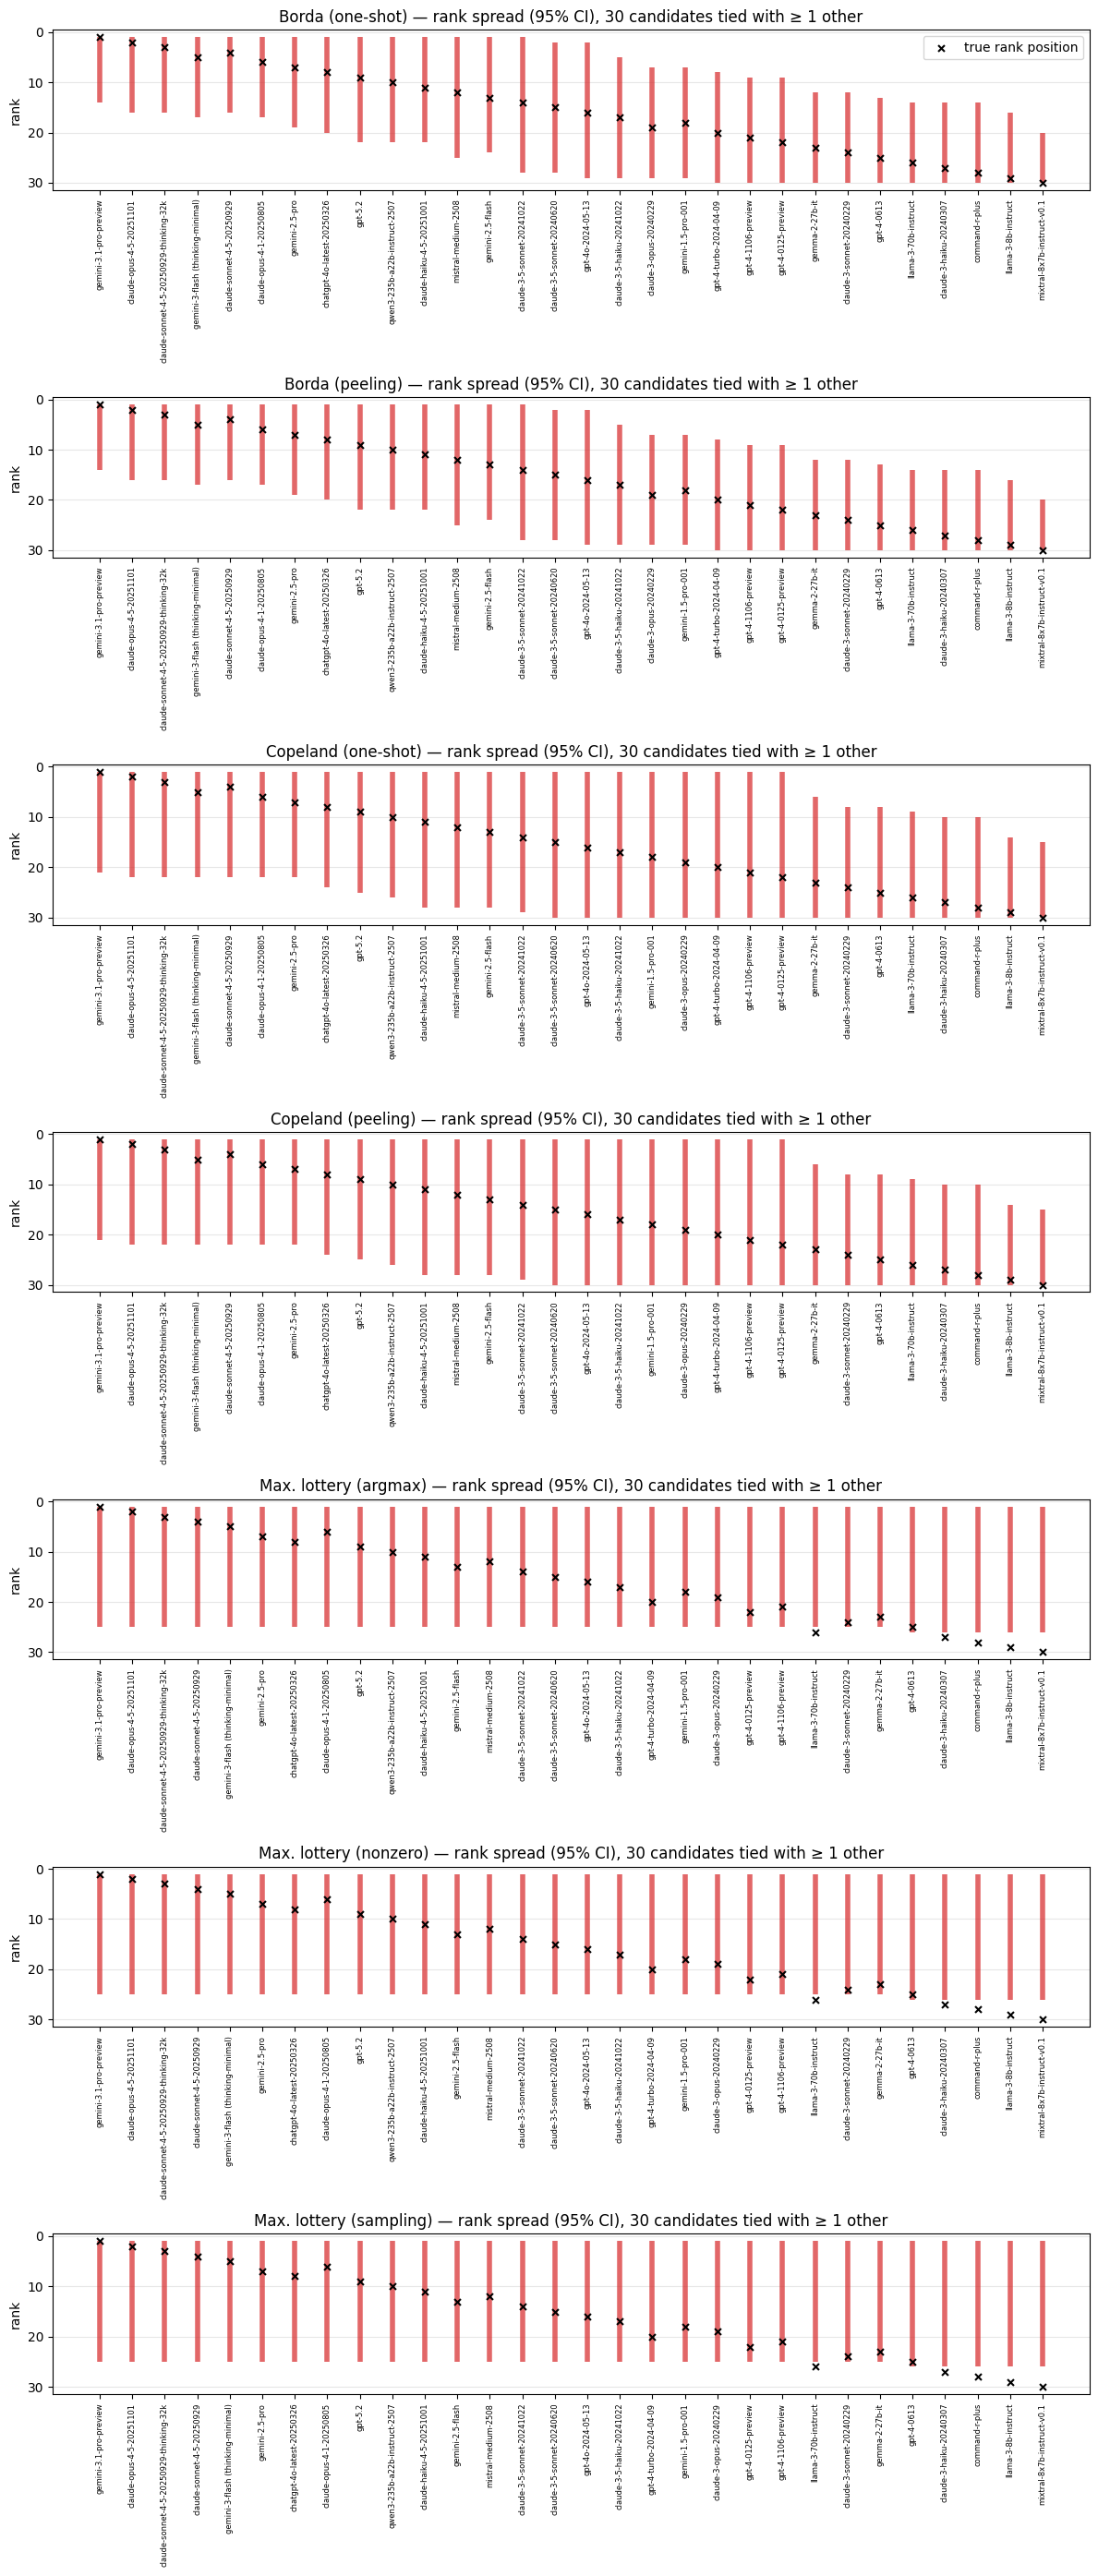

In [8]:
import matplotlib.pyplot as plt

labels = {
    'borda':            'Borda (one-shot)',
    'borda_peeling':    'Borda (peeling)',
    'copeland':         'Copeland (one-shot)',
    'copeland_peeling': 'Copeland (peeling)',
    'ml_argmax':        'Max. lottery (argmax)',
    'ml_nonzero':       'Max. lottery (nonzero)',
    'ml_sampling':      'Max. lottery (sampling)',
}

fig, axes = plt.subplots(len(methods), 1, figsize=(12, 4 * len(methods)))

for ax, method in zip(axes, methods):
    df = method_tables[method]
    x = np.arange(len(df))
    tied = df['n_tied_with'] > 0
    colors = np.where(tied, 'C3', 'C0')

    ax.vlines(x, df['best_rank'], df['worst_rank'], color=colors, linewidth=4, alpha=0.7)
    ax.scatter(x, df['true_rank_position'], color='black', marker='x', zorder=3, s=25,
               label='true rank position')

    ax.invert_yaxis()
    ax.set_xticks(x)
    ax.set_xticklabels(df['model_name'], rotation=90, fontsize=6)
    ax.set_ylabel('rank')
    ax.set_title(f'{labels[method]} — rank spread ({int(ci*100)}% CI), '
                 f'{(tied).sum()} candidates tied with ≥ 1 other')
    ax.grid(True, axis='y', alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()

### Caveat: the ML lottery score is degenerate under this construction

For `ml_argmax` / `ml_nonzero` / `ml_sampling`, the 95% CI lower bound (`ci_lo`) is `0.0` for essentially every candidate: the maximal-lottery LP puts positive weight on a sparse, shifting support set across bootstrap resamples, so the 2.5th percentile of any candidate's one-shot lottery weight is typically `0`. That collapses `best_rank` to `1` for all 30 candidates (nothing can be shown to necessarily outrank anything else) and makes every pair of candidates "tied" by the overlap definition.

It also produces the `true_rank_consistent = False` cases seen above: the bottom handful of candidates (`command-r-plus`, `claude-3-haiku-20240307`, `llama-3-70b-instruct`, `llama-3-8b-instruct`, `mixtral-8x7b-instruct-v0.1`) have `ci_hi = 0.0` too (they never appear in the LP support across any resample), giving them `worst_rank = 25`. Their true rank positions (26-30) fall outside that range, so the true ranking is technically "impossible" under this CI — not because the ranking method is wrong, but because a point-mass-at-zero score has no information to distinguish clearly-dominated candidates from each other.

This is a property of using a single-shot LP weight as the CI'd score (as opposed to Borda/Copeland's smoother win-rate statistics), not a bug in the rank-spread computation.